In [1]:
%load_ext autoreload
%autoreload 2

import json
import os
import numpy as np
import time

import matplotlib.pyplot as plt
from polyergalio.encoders.text_encoders import TextProcessor, DistortionTask
from polyergalio.encoders.tokenizer import SentencePieceTokenizer, TokenSequenceBuilder, fit_tokenizer, SPECIAL_TOKEN_PIECES, TokenSequenceBuilder
from polyergalio.encoders.pipeline import UniversalPipeline
from polyergalio.generators.data_generators import token_accuracy
from polyergalio.models.constants import DECISION_TYPES, ClassificationTask
from polyergalio.models.embedding.embedding import TextEmbedding
from polyergalio.models.embedding.positional import RopeEmbedding
from polyergalio.models.layers.basal_layers import DropoutLayer, FullyConnectedLayer, RMSNormLayer
from polyergalio.models.layers.decision_layers import (
    DecisionHead,
    decision_correct,
    decode_decisions,
    masked_softmax,
)
from polyergalio.models.layers.operator_layers import LatentSum, MaskGather
from polyergalio.models.layers.spectre_layers import SpectreAttention
from polyergalio.models.model_loss import CrossEntropyLoss, DecisionLoss
from polyergalio.models.neural_network import NeuralNetwork
from polyergalio.models.optimizers import Adam




In [2]:
# THIS IS SUPER KLUDGEY -- clean it up...

In [3]:
# TOKENIZER
TARGET_VOCAB_SIZE = 35_000
SEQUENCE_LENGTH = 512

corpus_path = f"../data/decision_data"
all_json = []

for fn in os.listdir(corpus_path):
    with open(f"{corpus_path}/{fn}", "r") as handle:
        for line in handle:
            try:
                all_json.append(json.loads(line))
            except:
                continue


In [4]:
print(len(all_json))

13000


In [5]:
# flatten out all of our strings for tokenizer fitting --
line_by_line = []
for sample in all_json:
    concat = ""
    for key, value in sample.items():
        concat += f"{key}: {value}\n"
    line_by_line.append(concat)

In [6]:
# model_path = fit_tokenizer(
#     corpus=line_by_line,
#     model_prefix=f"decision_tokenizer",
#     vocab_size=TARGET_VOCAB_SIZE,
#     hard_vocab_limit=False,
# )
#
# tokenizer = SentencePieceTokenizer(model_path)

In [7]:
# tokenizer
feature_encoder = UniversalPipeline(name="feature_encoder")
feature_encoder = feature_encoder.deserialize("spectre_decision_feature.pipeline")

In [8]:
# Starting -----
# tasks = (DistortionTask.CLOZE,
#          DistortionTask.REPLACED_TOKEN,
#          DistortionTask.TOKEN_DELETION,
#          )

text_processor = TextProcessor(feature_encoder["tokenizer"].tokenizer,
                               max_length=SEQUENCE_LENGTH,
                               replace_prob=0.15,
                               max_span_length=SEQUENCE_LENGTH,
                               # tasks=tasks,
                               )

feature_encoder = UniversalPipeline(name="feature_encoder")

In [9]:
text_processor.fit(line_by_line)

feature_encoder.connect(text_processor, name="tokenizer")
# feature_encoder.serialize("spectre_decision_feature.pipeline")
# print("feature serialized")

In [10]:
# ---------------------------------
# LOADING TEXT PIPELINE --
feature_encoder = UniversalPipeline(name="feature_encoder")
feature_encoder = feature_encoder.deserialize("spectre_decision_feature.pipeline")

print(feature_encoder["tokenizer"])


# double-checking ---
feature_encoder["tokenizer"].encode("this")

TextProcessor for text


{'text': array([[  3,  79,   4, ...,   0,   0,   0],
        [  3, 244,   4, ...,   0,   0,   0],
        [  3, 254,   4, ...,   0,   0,   0],
        [  3,  64,   4, ...,   0,   0,   0]], shape=(4, 512)),
 'text_attention_mask': array([[1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0]], shape=(4, 512))}

In [11]:
HIDDEN_DIM = 720
FFN_HIDDEN = 720
NUM_HEADS = 5
DROPOUT_PROB=0.10
PADDING_TOK = feature_encoder["tokenizer"].tokenizer.special_tokens.PAD

net = NeuralNetwork(name="spectre_transformer", input_shape=(SEQUENCE_LENGTH,))
embedding = net.connect(
    TextEmbedding(TARGET_VOCAB_SIZE, HIDDEN_DIM, padding_idx=PADDING_TOK), net.input, name="embedding"
)
positional = net.connect(RopeEmbedding(SEQUENCE_LENGTH, HIDDEN_DIM), embedding, name="positional_emb")


# ------ SpectreTF block
at = net.connect(RMSNormLayer(HIDDEN_DIM), positional, name="prenorm_0")
at = net.connect(SpectreAttention(SEQUENCE_LENGTH,
                                  HIDDEN_DIM,
                                  num_heads=NUM_HEADS,
                                  band_radius=32,
                                  memory_tokens=32,
                                  use_wrm=True), at, name="attention_0")
at = net.connect(FullyConnectedLayer(HIDDEN_DIM, FFN_HIDDEN, "swish"), at, name="ffna_0")
at = net.connect(FullyConnectedLayer(FFN_HIDDEN, HIDDEN_DIM, "swish"), at, name="ffnb_0")
at = net.connect(RMSNormLayer(HIDDEN_DIM), at, name="postnorm_0")
at = net.connect(DropoutLayer(DROPOUT_PROB), at, name="dropout_0")
at = net.connect(LatentSum(), at, positional, name="residual_0")

downsample= [32, 20, 20, 10, 10, 5, 5, 2, 2, 0, 0, 0, 0, 0, 0]
for block_idx in range(1, 12):
    use_wrm = (block_idx % 2) == 0
    # ------ SpectreTF blocks
    at = net.connect(RMSNormLayer(HIDDEN_DIM), at, name=f"prenorm_{block_idx}")
    at = net.connect(SpectreAttention(SEQUENCE_LENGTH,
                                      HIDDEN_DIM,
                                      num_heads=NUM_HEADS,
                                      band_radius=downsample[block_idx - 1],
                                      memory_tokens=20,
                                      use_wrm=use_wrm
                                      ), at, name=f"attention_{block_idx}")
    at = net.connect(FullyConnectedLayer(HIDDEN_DIM, FFN_HIDDEN, "swish"), at, name=f"ffna_{block_idx}")
    at = net.connect(FullyConnectedLayer(FFN_HIDDEN, HIDDEN_DIM, "swish"), at, name=f"ffnb_{block_idx}")
    at = net.connect(RMSNormLayer(HIDDEN_DIM), at, name=f"postnorm_{block_idx}")
    at = net.connect(DropoutLayer(DROPOUT_PROB), at, name=f"dropout_{block_idx}")
    at = net.connect(LatentSum(), at, positional, name=f"residual_{block_idx}")

gathered = net.connect(MaskGather(), at, name="mask_gather")
net.output = net.connect(
    FullyConnectedLayer(HIDDEN_DIM, TARGET_VOCAB_SIZE, "linear", is_output=True), gathered, name="mlm_head"
)

{'input': ((None,),), 'output': ((500,),)}
{'input': ((500,),), 'output': ((500,),)}
{'input': ((500,),), 'output': ((500,),)}
{'input': ((512, 500),), 'output': ((512, 500),)}
{'input': ((500,),), 'output': ((500,),)}
{'input': ((500,),), 'output': ((500,),)}
{'input': ((500,),), 'output': ((500,),)}
{'input': ((None,),), 'output': ((None,),)}
{'input': ((None,), (None,)), 'output': ((None,),)}
{'input': ((500,),), 'output': ((500,),)}
{'input': ((512, 500),), 'output': ((512, 500),)}
{'input': ((500,),), 'output': ((500,),)}
{'input': ((500,),), 'output': ((500,),)}
{'input': ((500,),), 'output': ((500,),)}
{'input': ((None,),), 'output': ((None,),)}
{'input': ((None,), (None,)), 'output': ((None,),)}
{'input': ((500,),), 'output': ((500,),)}
{'input': ((512, 500),), 'output': ((512, 500),)}
{'input': ((500,),), 'output': ((500,),)}
{'input': ((500,),), 'output': ((500,),)}
{'input': ((500,),), 'output': ((500,),)}
{'input': ((None,),), 'output': ((None,),)}
{'input': ((None,), (None

In [12]:
print(net.summary())

spectre_transformer: 88 nodes, 49282016 parameters
  node            sources                    shape
  embedding       input                      (512, 500)
  positional_emb  embedding                  (500,)
  prenorm_0       positional_emb             (500,)
  attention_0     prenorm_0                  (500,)
  ffna_0          attention_0                (500,)
  ffnb_0          ffna_0                     (500,)
  postnorm_0      ffnb_0                     (500,)
  dropout_0       postnorm_0                 (500,)
  residual_0      dropout_0,positional_emb   (None,)
  prenorm_1       residual_0                 (500,)
  attention_1     prenorm_1                  (500,)
  ffna_1          attention_1                (500,)
  ffnb_1          ffna_1                     (500,)
  postnorm_1      ffnb_1                     (500,)
  dropout_1       postnorm_1                 (500,)
  residual_1      dropout_1,positional_emb   (None,)
  prenorm_2       residual_1                 (500,)
  attent

edges:
  input      -> embedding
  embedding  -> positional_emb
  positional_emb -> prenorm_0
  prenorm_0  -> attention_0
  attention_0 -> ffna_0
  ffna_0     -> ffnb_0
  ffnb_0     -> postnorm_0
  postnorm_0 -> dropout_0
  dropout_0  -> residual_0
  positional_emb -> residual_0
  residual_0 -> prenorm_1
  prenorm_1  -> attention_1
  attention_1 -> ffna_1
  ffna_1     -> ffnb_1
  ffnb_1     -> postnorm_1
  postnorm_1 -> dropout_1
  dropout_1  -> residual_1
  positional_emb -> residual_1
  residual_1 -> prenorm_2
  prenorm_2  -> attention_2
  attention_2 -> ffna_2
  ffna_2     -> ffnb_2
  ffnb_2     -> postnorm_2
  postnorm_2 -> dropout_2
  dropout_2  -> residual_2
  positional_emb -> residual_2
  residual_2 -> prenorm_3
  prenorm_3  -> attention_3
  attention_3 -> ffna_3
  ffna_3     -> ffnb_3
  ffnb_3     -> postnorm_3
  postnorm_3 -> dropout_3
  dropout_3  -> residual_3
  positional_emb -> residual_3
  residual_3 -> prenorm_4
  prenorm_4  -> attention_4
  attention_4 -> ffna_4
  ffna

<Axes: title={'center': 'spectre_transformer'}>

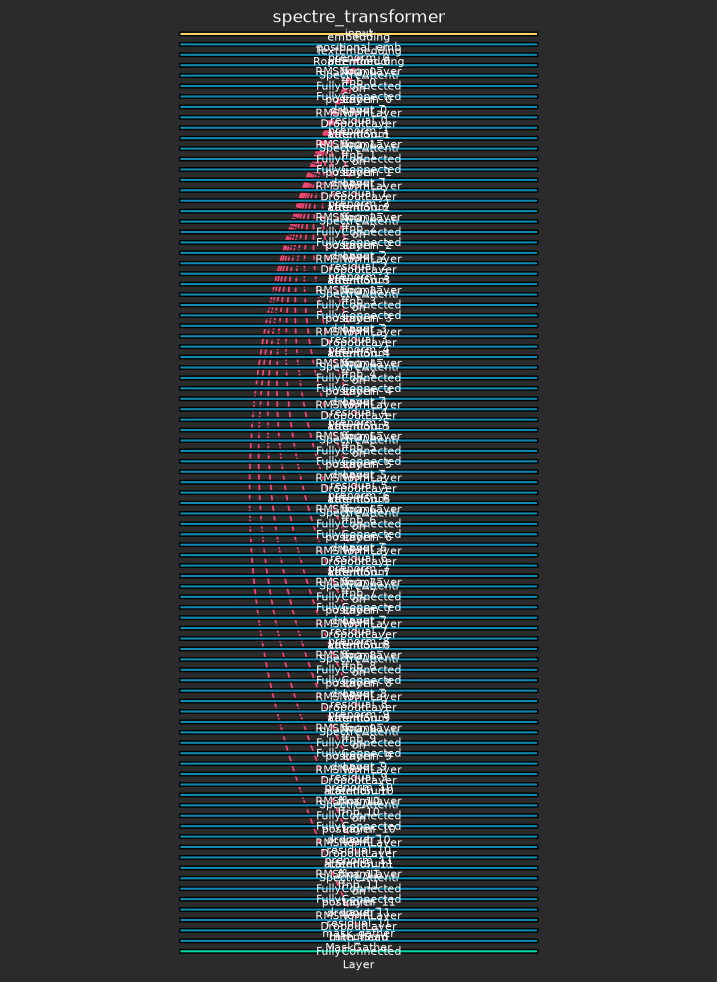

In [13]:
from polyergalio.visuals.nnet_visuals import plot_network

print("edges:")
for producer, consumer in net.edges():
    print(f"  {producer:10s} -> {consumer}")
_temp = text_processor.encode("this is a go")
print(net.summary(_temp["text"]))
print(net.timing_summary(top=10))
plot_network(net)

In [14]:
def mlm_accuracy(net: NeuralNetwork, processor: TextProcessor, texts: list[str]) -> float:
    """Accuracy at masked positions of a cloze batch, with the network in eval mode."""
    batch = processor.distort_batch(texts, "cloze")
    net.eval()
    logits = net.forward(batch["input_ids"], mask=batch["attention_mask"], target_mask=batch["target_mask"])
    return token_accuracy(np.argmax(logits, axis=-1), batch["labels"][batch["target_mask"]])

print(net)

NeuralNetwork(88 nodes, 49282016 parameters)


In [15]:
# feature_encoder pipeline needs to have visibility into these subprocesses:
data = feature_encoder["tokenizer"].distort_batch(line_by_line[0:5])
data.keys()

dict_keys(['input_ids', 'attention_mask', 'segment_ids', 'target_mask', 'labels', 'task'])

In [16]:
held_out = []
training = []
samples = np.random.choice([True, False], replace=True, size=len(line_by_line), p=[0.05, 0.95])
for idx, hold in enumerate(samples):
    if hold == True:
        held_out.append(line_by_line[idx])
    else:
        training.append(line_by_line[idx])

print(len(held_out))
print(len(training))

688
12312


In [17]:
# deserialize
net = net.deserialize("spectre_nnet.ergalio")

{'input': ((None,),), 'output': ((720,),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((512, 720),), 'output': ((512, 720),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((None,),), 'output': ((None,),)}
{'input': ((None,), (None,)), 'output': ((None,),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((512, 720),), 'output': ((512, 720),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((None,),), 'output': ((None,),)}
{'input': ((None,), (None,)), 'output': ((None,),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((512, 720),), 'output': ((512, 720),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((None,),), 'output': ((None,),)}
{'input': ((None,), (None

training will take 1232.2 steps
replaced_token
mlm step    0  loss 0.1358
took 7.7053422927856445


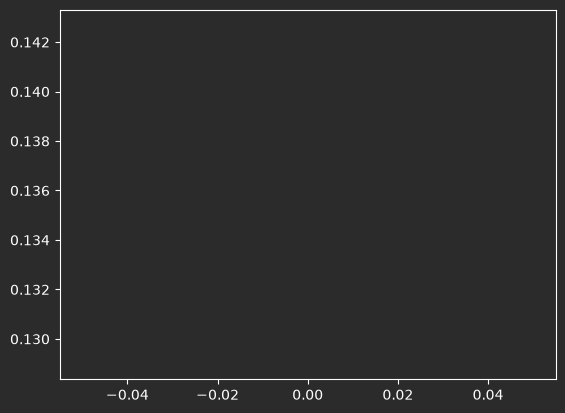

masked-token accuracy after training:  0.896
text_infilling
mlm step   50  loss 0.8541
took 5.424130201339722


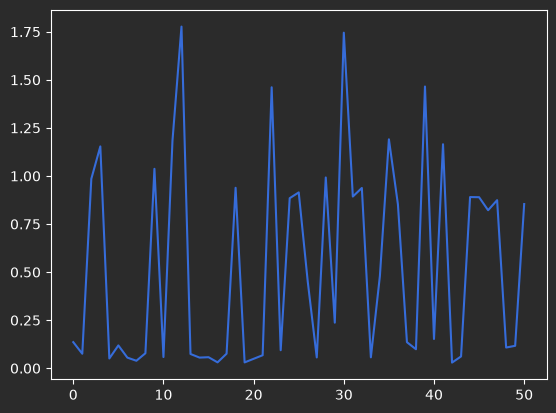

masked-token accuracy after training:  0.891
text_infilling
mlm step  100  loss 0.8957
took 5.243661165237427


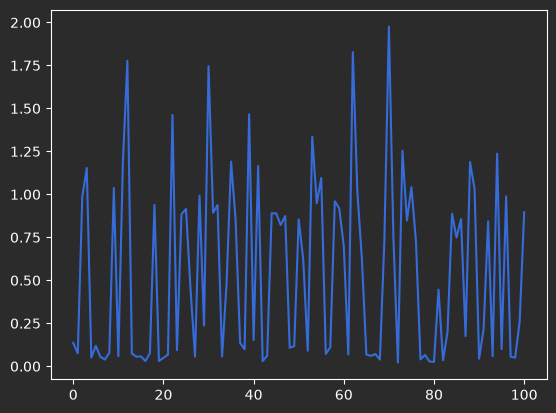

masked-token accuracy after training:  0.882
replaced_token
mlm step  150  loss 0.0610
took 7.383371114730835


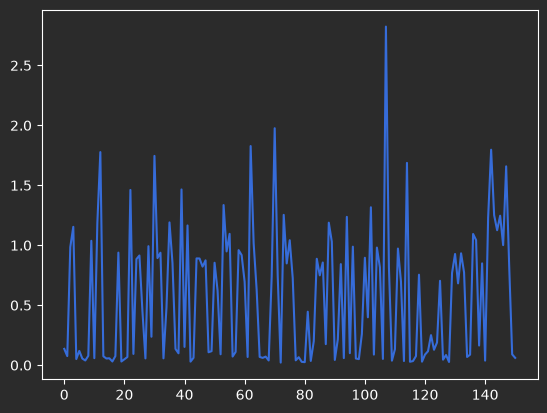

masked-token accuracy after training:  0.837
text_infilling
mlm step  200  loss 0.9883
took 5.881908893585205


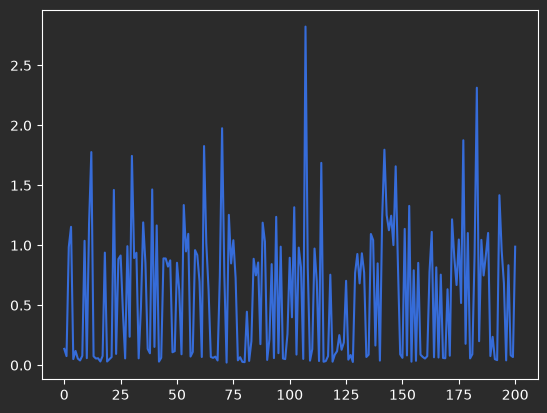

masked-token accuracy after training:  0.831
cloze
mlm step  250  loss 1.2129
took 6.010310173034668


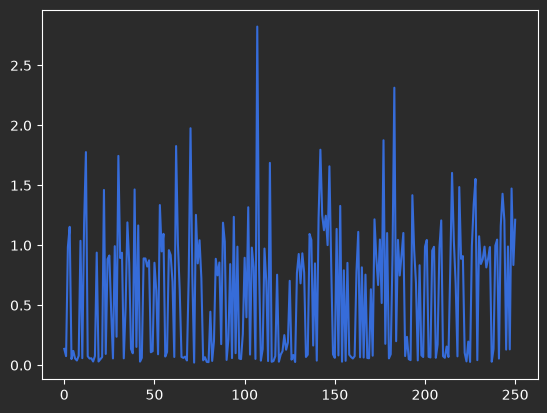

masked-token accuracy after training:  0.866
replaced_token
mlm step  300  loss 0.1102
took 6.266068935394287


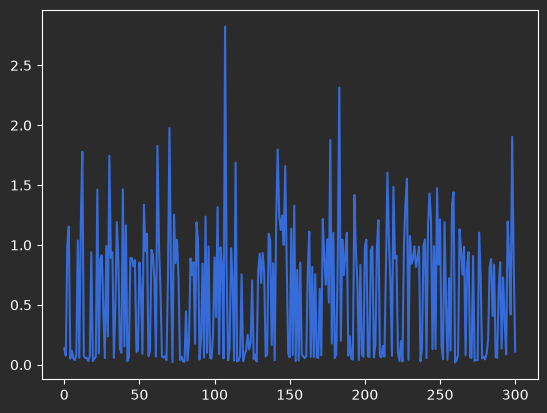

masked-token accuracy after training:  0.854


KeyboardInterrupt: 

In [23]:
BATCH_SIZE = 10
LR = 4e-4
EPOCHS = 10
LOG_EVERY = 50
_targets = np.eye(TARGET_VOCAB_SIZE)

all_loss = []
loss_fn = CrossEntropyLoss(task=ClassificationTask.MULTINOMIAL)
optimizer = Adam(LR)

for epoch in range(5, EPOCHS):
    np.random.shuffle(training)
    optimizer.learning_rate = LR * (0.92 ** epoch)
    print(f"training will take {len(training) / BATCH_SIZE} steps")

    for step, start_idx in enumerate(range(0, len(training), BATCH_SIZE)):
        net.train()
        _mini_batch = training[start_idx:start_idx+BATCH_SIZE]
        _tok_batch = text_processor.distort_batch(_mini_batch)

        tokens, labels = _tok_batch["input_ids"],  _tok_batch["labels"]
        attention_mask, target_mask = _tok_batch["attention_mask"],  _tok_batch["target_mask"]
        targets = labels[target_mask]

        st = time.time()
        logits = net.forward(tokens, mask=attention_mask, target_mask=target_mask)

        loss = loss_fn(logits, _targets[targets])
        stt = time.time() - st

        net.backward(loss_fn.backward())
        optimizer.step(net.layers)
        net.zero_gradients()
        all_loss.append(loss.item())

        if step % LOG_EVERY == 0:
            print(_tok_batch["task"])
            print(f"mlm step {step:4d}  loss {loss:.4f}")
            print(f"took {stt}")
            plt.plot(all_loss)
            plt.show()
            print(f"masked-token accuracy after training:  {mlm_accuracy(net, text_processor, held_out[:BATCH_SIZE]):.3f}")

        # net.serialize("spectre_nnet.ergalio")

    print(f"masked-token accuracy after training:  {mlm_accuracy(net, text_processor, held_out[:BATCH_SIZE]):.3f}")


In [23]:
# net.serialize("spectre_nnet.ergalio")

{'type': 'NeuralNetwork',
 'version': '0.1.4',
 'config': {'name': 'spectre_transformer', 'input_shape': (512,)},
 'weights': {'nodes': [{'name': 'embedding',
    'sources': ['input'],
    'component': {'type': 'TextEmbedding',
     'version': '0.1.4',
     'config': {'num_embeddings': 35000,
      'embedding_dim': 720,
      'padding_idx': 0,
      'special_tokens': None,
      'initialization': 'truncated_normal',
      'initialization_kwargs': {}},
     'weights': {'weights': array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
               0.        ,  0.        ],
             [ 0.01803046, -0.02419441,  0.00903622, ...,  0.00614663,
               0.01864759,  0.01185931],
             [-0.00509322,  0.02190727,  0.00185429, ...,  0.00151834,
               0.0094983 ,  0.01779077],
             ...,
             [-0.00160673, -0.00295732,  0.01611739, ..., -0.01255633,
              -0.00618509,  0.00524729],
             [ 0.02679031,  0.00518633,  0.02107045, ...

In [31]:
# deserialize
net = net.deserialize("spectre_nnet.ergalio")

{'input': ((None,),), 'output': ((720,),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((512, 720),), 'output': ((512, 720),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((None,),), 'output': ((None,),)}
{'input': ((None,), (None,)), 'output': ((None,),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((512, 720),), 'output': ((512, 720),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((None,),), 'output': ((None,),)}
{'input': ((None,), (None,)), 'output': ((None,),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((512, 720),), 'output': ((512, 720),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((None,),), 'output': ((None,),)}
{'input': ((None,), (None

{'input': ((None, None, 720),), 'output': ((None,),)}


<Axes: title={'center': 'spectre_transformer'}>

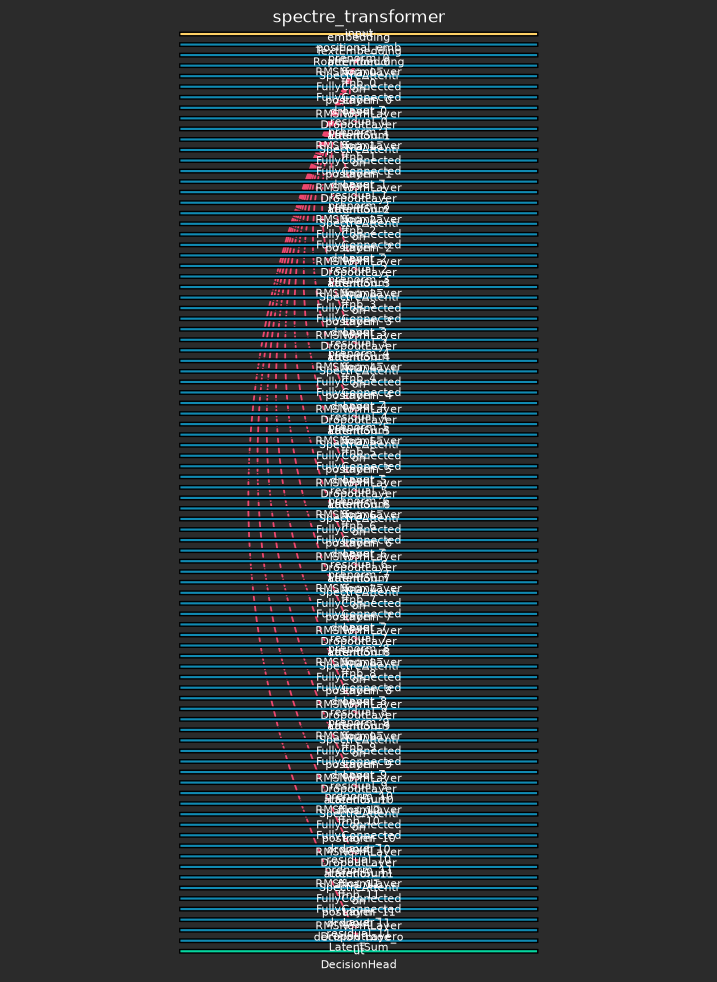

In [32]:
HIDDEN_DIM = 720
net.output = net.connect(DecisionHead(hidden_dim=HIDDEN_DIM,
                                      head_hidden=HIDDEN_DIM,
                                      routed_scaling=1.5,
                                      num_groups=16,
                                      top_groups=8),
                         net.node("residual_11"),
                         name="decision_moe_out")

net.disconnect(net.node("decision_moe"))
net.delete(net.node("decision_moe"))

net.purge()
plot_network(net)

In [33]:
# how to disconnect / reconnect ----------
# pooler = net.connect(PoolingLayer(),
#                      net.node("residual_11"),
#                      name="pooling")
# HIDDEN_DIM=720
#
# net.output = net.connect(DecisionHead(hidden_dim=HIDDEN_DIM,
#                                       head_hidden=HIDDEN_DIM),
#                          net.node("residual_11"),
#                          name="decision_moe")
#
# net.disconnect(net.node("mask_gather"))
# net.delete(net.node("mask_gather"))
# net.disconnect(net.node("mlm_head"))
# net.delete(net.node("mlm_head"))
#
# net.purge()
# plot_network(net)


task_processor = TokenSequenceBuilder(tokenizer)

task_processor.build_decision_batch(samples, max_length=None)

## yields :
token_ids (batch, sequence_length)
mask (batch, sequence_length) — the encoder's attention mask, token_ids != PAD
marker_pos -> marker token positions (the start of a span)
marker_end -> marker_end token positions (the ending of a span)
token_mask (batch, options) — DecisionHead's own kwargs
decisiontypes (batch,) - one Enum per task
answers (batch,), included only when every sample carries an answer

In [25]:

sample = [
    {"id": 0,
     "decisiontype": "choice",
     "instructions": "What should be done with this inventory item?",
     "options": ["reorder", "discount", "hold", "discontinue"],

     "state": {"sku": "SKU-4122", "item": "HDMI cable", "stock": 324, "weekly_sales": 1, "days_to_expiry": None},
     "answer": 3,
     "option": "discontinue",
     "record": {"sku": "SKU-4122", "item": "HDMI cable", "stock": 324, "weekly_sales": 1, "days_to_expiry": None}
     },
          {"id": 0,
     "decisiontype": "choice",
     "instructions": "What should be done with this inventory item?",
     "options": ["reorder", "discount", "hold", "discontinue"],

     "state": {"sku": "SKU-4122", "item": "HDMI cable", "stock": 324, "weekly_sales": 1, "days_to_expiry": None},
     "answer": 3,
     "option": "discontinue",
     "record": {"sku": "SKU-4122", "item": "HDMI cable", "stock": 324, "weekly_sales": 1, "days_to_expiry": None}
     }
          ]


task_processor = TokenSequenceBuilder(feature_encoder["tokenizer"].tokenizer)

# task_processor.build_decision_batch
batch = task_processor.build_decision_batch(sample, max_length=512)
# target = (batch["answer"], batch["option"])


print("edges:")
for producer, consumer in net.edges():
    print(f"  {producer:10s} -> {consumer}")

st = time.time()
logits = net.forward(batch["token_ids"],
                     mask=batch["mask"],
                     marker_pos=batch["marker_pos"],
                     marker_end=batch["marker_end"],
                     token_mask=batch["token_mask"],
                     decisiontypes=batch["decisiontypes"])
print(f'naive forward took {(time.time() - st) / len(sample)} per sample row')
print(net.timing_summary(top=10))


edges:
  input      -> embedding
  embedding  -> positional_emb
  positional_emb -> prenorm_0
  prenorm_0  -> attention_0
  attention_0 -> ffna_0
  ffna_0     -> ffnb_0
  ffnb_0     -> postnorm_0
  postnorm_0 -> dropout_0
  dropout_0  -> residual_0
  positional_emb -> residual_0
  residual_0 -> prenorm_1
  prenorm_1  -> attention_1
  attention_1 -> ffna_1
  ffna_1     -> ffnb_1
  ffnb_1     -> postnorm_1
  postnorm_1 -> dropout_1
  dropout_1  -> residual_1
  positional_emb -> residual_1
  residual_1 -> prenorm_2
  prenorm_2  -> attention_2
  attention_2 -> ffna_2
  ffna_2     -> ffnb_2
  ffnb_2     -> postnorm_2
  postnorm_2 -> dropout_2
  dropout_2  -> residual_2
  positional_emb -> residual_2
  residual_2 -> prenorm_3
  prenorm_3  -> attention_3
  attention_3 -> ffna_3
  ffna_3     -> ffnb_3
  ffnb_3     -> postnorm_3
  postnorm_3 -> dropout_3
  dropout_3  -> residual_3
  positional_emb -> residual_3
  residual_3 -> prenorm_4
  prenorm_4  -> attention_4
  attention_4 -> ffna_4
  ffna

In [26]:
batch

{'token_ids': array([[   3,  126, 1293, ...,    0,    0,    0],
        [   3,  126, 1293, ...,    0,    0,    0]], shape=(2, 512)),
 'mask': array([[ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False]], shape=(2, 512)),
 'marker_pos': array([[12, 14, 16, 18],
        [12, 14, 16, 18]]),
 'marker_end': array([[14, 16, 18, 20],
        [14, 16, 18, 20]]),
 'token_mask': array([[ True,  True,  True,  True],
        [ True,  True,  True,  True]]),
 'decisiontypes': array([1, 1]),
 'answers': array([3, 3])}

In [27]:
loss = DecisionLoss(ordinal_weight=0.25)(logits,
                                         batch["answers"],
                                         batch["token_mask"],
                                         batch["decisiontypes"])

print(loss)
print(logits)

1.4066252494560643
[[ 0.35072658  1.10394418  0.92431858  1.10422301]
 [-0.16821449  0.30993522  1.02211147  0.21049219]]


In [48]:
print(net)
# 159_260_541

NeuralNetwork(87 nodes, 121065759 parameters)


In [34]:
held_out = []
training = []
samples = np.random.choice([True, False], replace=True, size=len(all_json), p=[0.05, 0.95])

for idx, hold in enumerate(samples):
    if hold == True:
        held_out.append(all_json[idx])
    else:
        training.append(all_json[idx])

print(len(held_out))
print(len(training))

648
12352


training will take 2470.4 steps
decision_types:  [0 1 1 1 1]
answer_targets:  [0 0 2 0 1]
predicted:       [0 1 2 1 0]
esc? :  [False False False False False]
Losses for step    0 
	- Decision loss 5.7648 
	- Confidence loss 0.7963 


<Figure size 640x480 with 0 Axes>

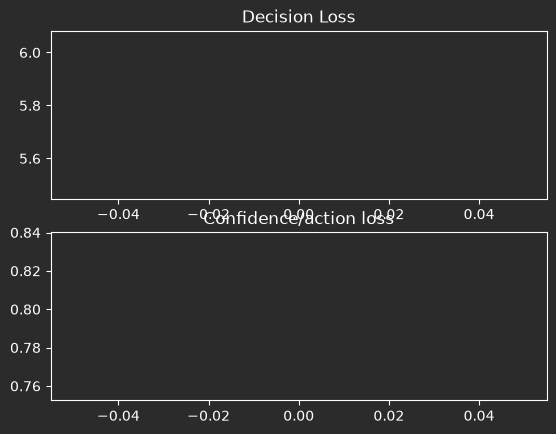

decision_types:  [2 1 1 1 1]
answer_targets:  [3 4 0 1 4]
predicted:       [4 1 1 1 3]
esc? :  [False False False False False]
Losses for step   20 
	- Decision loss 1.5759 
	- Confidence loss -5.1393 


<Figure size 640x480 with 0 Axes>

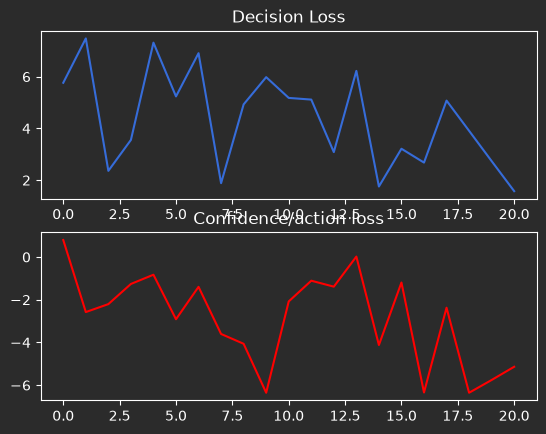

decision_types:  [0 1 1 1 1]
answer_targets:  [1 2 3 3 1]
predicted:       [1 3 5 3 3]
esc? :  [False False False False False]
Losses for step   40 
	- Decision loss 1.8183 
	- Confidence loss -4.4436 


<Figure size 640x480 with 0 Axes>

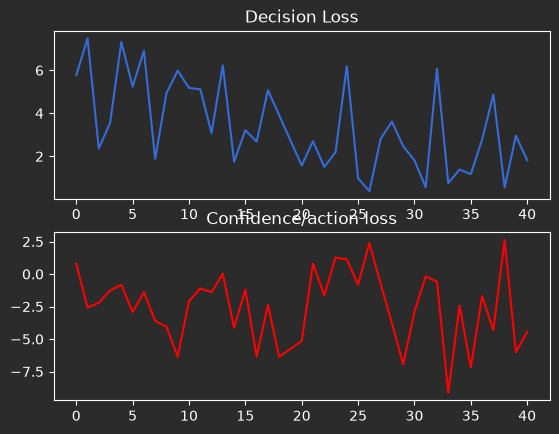

decision_types:  [1 1 1 1 1]
answer_targets:  [2 0 5 4 5]
predicted:       [5 2 3 2 5]
esc? :  [False False False False False]
Losses for step   60 
	- Decision loss 1.9889 
	- Confidence loss -11.7744 


<Figure size 640x480 with 0 Axes>

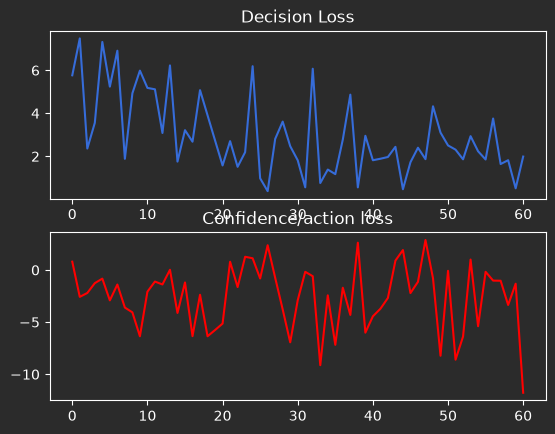

decision_types:  [0 2 1 0 1]
answer_targets:  [0 3 4 1 3]
predicted:       [0 0 0 0 0]
esc? :  [False False False False False]
Losses for step   80 
	- Decision loss 6.2737 
	- Confidence loss -8.6498 


<Figure size 640x480 with 0 Axes>

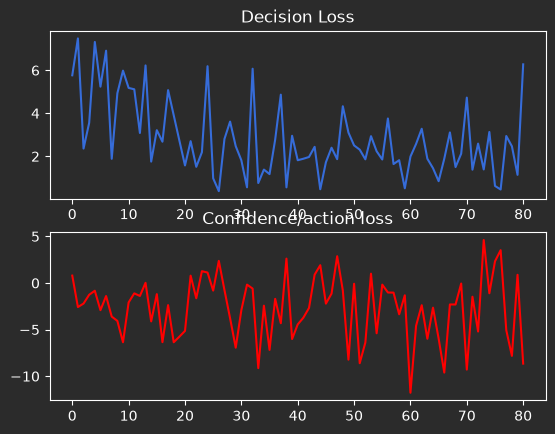

decision_types:  [1 1 1 1 0]
answer_targets:  [0 0 1 2 1]
predicted:       [1 0 2 3 1]
esc? :  [False False False False False]
Losses for step  100 
	- Decision loss 1.0352 
	- Confidence loss 1.6024 


<Figure size 640x480 with 0 Axes>

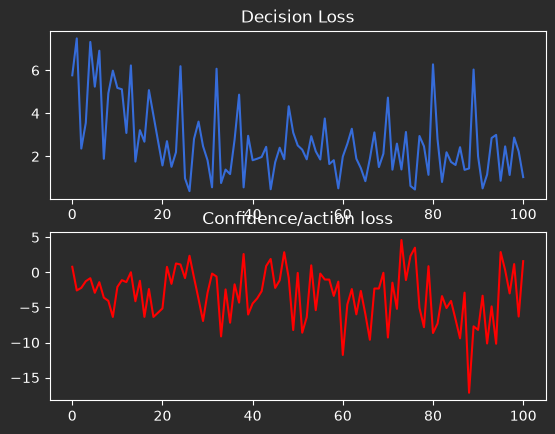

decision_types:  [1 2 0 1 0]
answer_targets:  [0 2 0 2 0]
predicted:       [0 4 1 0 1]
esc? :  [False False False False False]
Losses for step  120 
	- Decision loss 1.8808 
	- Confidence loss 1.0918 


<Figure size 640x480 with 0 Axes>

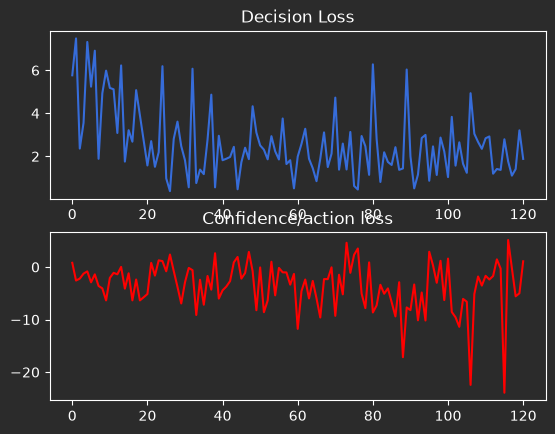

In [ ]:
BATCH_SIZE = 5
LR =2e-4
ACT_WEIGHT = 0.01
EPOCHS = 10
LOG_EVERY = 20

all_loss, all_act_loss = [], []
loss_fn = DecisionLoss(ordinal_weight=0.2)
task_processor = TokenSequenceBuilder(feature_encoder["tokenizer"].tokenizer)
optimizer = Adam(LR)

for epoch in range(1, EPOCHS):
    np.random.shuffle(training)
    optimizer.learning_rate = LR * (0.92 ** epoch)
    net.node("decision_moe_out").component.act_weight = ACT_WEIGHT * (1.5 ** epoch)
    print(f"training will take {len(training) / BATCH_SIZE} steps")

    net.eval()
    net.node("decision_moe_out").component.train()

    for step, start_idx in enumerate(range(0, len(training), BATCH_SIZE)):

        _mini_batch = training[start_idx:start_idx+BATCH_SIZE]
        _tok_batch = task_processor.build_decision_batch(
            _mini_batch,
            max_length=SEQUENCE_LENGTH)
        # target = (sample["answer"], sample["option"])

        logits = net.forward(_tok_batch["token_ids"],
                             mask=_tok_batch["mask"],
                             marker_pos=_tok_batch["marker_pos"],
                             marker_end=_tok_batch["marker_end"],
                             token_mask=_tok_batch["token_mask"],
                             decisiontypes=_tok_batch["decisiontypes"])

        act = net.node("decision_moe_out").component.score_act(_tok_batch["answers"])

        loss = loss_fn(logits,
                       _tok_batch["answers"],
                       _tok_batch["token_mask"],
                       _tok_batch["decisiontypes"])


        net.backward(loss_fn.backward())
        optimizer.step(net.layers)
        net.zero_gradients()
        all_loss.append(loss)
        all_act_loss.append(act)


        if step % LOG_EVERY == 0:
            plt.clf()
            print("decision_types: ", _tok_batch["decisiontypes"])
            print("answer_targets: ", _tok_batch["answers"])
            print("predicted:      ", np.argmax(logits, axis=-1))
            print("esc? : ", net.node("decision_moe_out").component.escalate(0.5))
            print(f"Losses for step {step:4d} \n\t- Decision loss {loss:.4f} \n\t- Confidence loss {act:.4f} ")
            plt.figure()
            plt.subplot(2,1,1)
            plt.title("Decision Loss")
            plt.plot(all_loss)
            plt.subplot(2,1,2)
            plt.title("Confidence/action loss")
            plt.plot(all_act_loss, color="red")
            plt.show()

    net.serialize("spectre_nnet_decider.ergalio")


In [ ]:
net.serialize("spectre_nnet_decider.ergalio")